# Analysis of model results

## Imports

In [1]:
import arviz as az
import bambi as bmb
import polars as  pl
import numpy as np
import pandas as pd

from matplotlib import pyplot as plt

from kidney.paths import RESULTS_DIR, PREPARED_FILES, PLOT_DIR
from kidney.plotting import forestplot_oz, plot_ppc
from kidney.sign_probs import get_sign_probs, get_signif

In [2]:
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['font.family'] = 'Arial'

## Configuration

In [3]:
az.rcParams["data.load"] = "eager"

## PB analysis

In [7]:
idata_bp_empa = az.from_netcdf(RESULTS_DIR / "idata_bp_empa.nc")
idata_bp_vehicle = az.from_netcdf(RESULTS_DIR / "idata_bp_vehicle.nc")
idata_bp_bsl = az.from_netcdf(RESULTS_DIR / "idata_bp_baseline.nc")

idata_bp_bsl

Inference data with groups:
	> posterior
	> posterior_predictive
	> log_likelihood
	> sample_stats
	> observed_data

# Compute group values

In [8]:
t_groups_empa, t_groups_vehicle, t_groups_bsl = (
    {
        "fa/+:female:adult":   idata.posterior["Intercept"],
        "fa/+:female:young":   idata.posterior["Intercept"] + idata.posterior["age"],
        "fa/+:male:adult":     idata.posterior["Intercept"] + idata.posterior["sex"],
        "fa/+:male:young":     idata.posterior["Intercept"] + idata.posterior["sex"] + idata.posterior["age"],
        "fa/fa:female:adult":  idata.posterior["Intercept"] + idata.posterior["gtyp"],
        "fa/fa:female:young":  idata.posterior["Intercept"] + idata.posterior["gtyp"] + idata.posterior["age"] + idata.posterior["gtyp:age"],
        "fa/fa:male:adult":    idata.posterior["Intercept"] + idata.posterior["gtyp"] + idata.posterior["sex"] + idata.posterior["gtyp:sex"],
        "fa/fa:male:young":    idata.posterior["Intercept"] + idata.posterior["gtyp"] + idata.posterior["sex"] + idata.posterior["gtyp:sex"] + idata.posterior["age"] + idata.posterior["gtyp:age"],
    }
    for idata in (idata_bp_empa, idata_bp_vehicle, idata_bp_bsl)
)

In [9]:
ts_empa, ts_vehicle, ts_bsl = (
    {
    "fa/fa adult M":   t_groups["fa/fa:male:adult"],
    "fa/fa young M":   t_groups["fa/fa:male:young"],
    "fa/+ adult M":    t_groups["fa/+:male:adult"],
    "fa/+ young M":    t_groups["fa/+:male:young"],
    "fa/fa adult F":   t_groups["fa/fa:female:adult"],
    "fa/fa young F":   t_groups["fa/fa:female:young"],
    "fa/+ adult F":    t_groups["fa/+:female:adult"],
    "fa/+ young F":    t_groups["fa/+:female:young"],
        "fa/+": (t_groups["fa/+:female:young"] + t_groups["fa/+:female:adult"] + t_groups["fa/+:male:young"] + t_groups["fa/+:male:adult"])/4,
        "fa/fa": (t_groups["fa/fa:female:young"] + t_groups["fa/fa:female:adult"] + t_groups["fa/fa:male:young"] + t_groups["fa/fa:male:adult"])/4,
    }
    for t_groups in (t_groups_empa, t_groups_vehicle, t_groups_bsl)
)

sign_probabilities_change = pd.DataFrame({
    'empa':get_sign_probs(ts_empa),
    'empa_signif':{k:get_signif(v) for k,v in get_sign_probs(ts_empa).items()},
    'vehicle':get_sign_probs(ts_vehicle),
    'vehicle_signif':{k:get_signif(v) for k,v in get_sign_probs(ts_vehicle).items()}
})

print("Empa sign probabilities:")
display(get_sign_probs(ts_empa))
print("\nVehicle sign probabilities:")
display(get_sign_probs(ts_vehicle))

Empa sign probabilities:


{'fa/fa adult M': 0.0,
 'fa/fa young M': 0.00025,
 'fa/+ adult M': 0.7345,
 'fa/+ young M': 0.763,
 'fa/fa adult F': 0.12575,
 'fa/fa young F': 0.58875,
 'fa/+ adult F': 0.98025,
 'fa/+ young F': 0.93675,
 'fa/+': 0.98,
 'fa/fa': 0.00025}


Vehicle sign probabilities:


{'fa/fa adult M': 0.9115,
 'fa/fa young M': 0.40625,
 'fa/+ adult M': 0.94025,
 'fa/+ young M': 0.963,
 'fa/fa adult F': 0.99725,
 'fa/fa young F': 0.8445,
 'fa/+ adult F': 0.9935,
 'fa/+ young F': 0.97,
 'fa/+': 0.9995,
 'fa/fa': 0.9765}

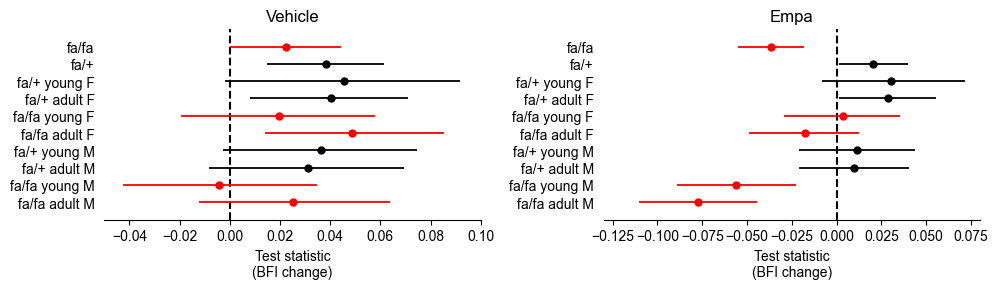

In [13]:
f, axes = plt.subplots(1, 2, figsize=(10, 3))
axes[1] = forestplot_oz(axes[1], ts_empa);
axes[1].set_title("Empa");

axes[0] = forestplot_oz(axes[0], ts_vehicle);
axes[0].set_title("Vehicle");

for ax in axes:
    ax.spines[['top', 'right', 'left']].set_visible(False)
    ax.set_xlabel('Test statistic\n(BFI change)')

axes[0].set_xlim(-0.05, 0.1)
axes[1].set_xlim(-0.13, 0.08)


f.tight_layout()
# f.savefig(PLOT_DIR / "ts_bp_groups.pdf", bbox_inches="tight")

## TS representing the difference between fa/fa and fa/+

In [14]:
ts_empa, ts_vehicle, ts_bsl = (
    {
        "M adult":   t_groups["fa/fa:male:adult"] - t_groups["fa/+:male:adult"],
        "M young":   t_groups["fa/fa:male:young"] - t_groups["fa/+:male:young"],
        "F adult": t_groups["fa/fa:female:adult"] - t_groups["fa/+:female:adult"],
        "F young": t_groups["fa/fa:female:young"] - t_groups["fa/+:female:young"],
        "overall": ((t_groups["fa/fa:male:adult"] - t_groups["fa/+:male:adult"] + t_groups["fa/fa:female:adult"] - t_groups["fa/+:female:adult"])/2 \
                     + (t_groups["fa/fa:male:young"] - t_groups["fa/+:male:young"] + t_groups["fa/fa:female:young"] - t_groups["fa/+:female:young"])/2)/2,
        
    }
    for t_groups in (t_groups_empa, t_groups_vehicle, t_groups_bsl)
)

sign_probabilities_gtyp = pd.DataFrame({
    'empa':get_sign_probs(ts_empa),
    'empa_signif':{k:get_signif(v) for k,v in get_sign_probs(ts_empa).items()},
    'vehicle':get_sign_probs(ts_vehicle),
    'vehicle_signif':{k:get_signif(v) for k,v in get_sign_probs(ts_vehicle).items()},
    'baseline1':get_sign_probs(ts_bsl),
    'baseline1_signif':{k:get_signif(v) for k,v in get_sign_probs(ts_bsl).items()}
})

print("Empa sign probabilities:")
display(get_sign_probs(ts_empa))
print("\nVehicle sign probabilities:")
display(get_sign_probs(ts_vehicle))
print("\nBaseline sign probabilities:")
display(get_sign_probs(ts_bsl))

Empa sign probabilities:


{'M adult': 0.0,
 'M young': 0.00325,
 'F adult': 0.0125,
 'F young': 0.151,
 'overall': 0.0}


Vehicle sign probabilities:


{'M adult': 0.419,
 'M young': 0.073,
 'F adult': 0.65,
 'F young': 0.19475,
 'overall': 0.158}


Baseline sign probabilities:


{'M adult': 0.5575,
 'M young': 0.74575,
 'F adult': 0.03475,
 'F young': 0.18225,
 'overall': 0.228}

[]

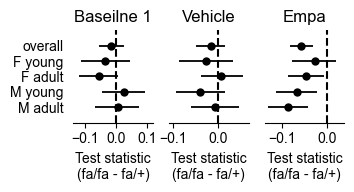

In [15]:
f, axes = plt.subplots(1, 3, figsize=(3.5, 1.2))
plt.subplots_adjust(wspace=0.2)

for ax, ts_, tle in zip(axes, (ts_bsl, ts_vehicle, ts_empa), ('Baseilne 1', 'Vehicle', 'Empa')):
    ax = forestplot_oz(ax, ts_);
    ax.set_title(tle);
    ax.spines[['top', 'right', 'left']].set_visible(False)
    ax.set_xlabel('Test statistic\n(fa/fa - fa/+)')

axes[0].set_xlim(-0.14,0.12)
axes[1].set_xlim(-0.11, 0.07)
axes[2].set_xlim(-0.14, 0.04)

axes[2].set_yticks([],[])
axes[1].set_yticks([],[])
# plt.tight_layout()
# f.savefig(PLOT_DIR / "ts_bp_CompareGtypForAgesSexes.pdf", bbox_inches="tight")

## TS representing the difference between young and adult

In [16]:
ts_empa, ts_vehicle, ts_bsl = (
    {
        "fa/fa":   t_groups["fa/fa:male:young"] - t_groups["fa/fa:male:adult"],
        "fa/+":   t_groups["fa/+:male:young"] - t_groups["fa/+:male:adult"],
        # "F fa/fa":  t_groups["fa/fa:female:young"] - t_groups["fa/fa:female:adult"],
        # "F fa/+":   t_groups["fa/+:female:young"] - t_groups["fa/+:female:adult"],
        # "adult": (t_groups["fa/fa:male:adult"] - t_groups["fa/+:male:adult"] + t_groups["fa/fa:female:adult"] - t_groups["fa/+:female:adult"])/2,
        # "young": (t_groups["fa/fa:male:young"] - t_groups["fa/+:male:young"] + t_groups["fa/fa:female:young"] - t_groups["fa/+:female:young"])/2,
        # "overall": (t_groups["fa/fa:young"]+t_groups["fa/fa:old"])/2 - (t_groups["fa/+:young"]+t_groups["fa/+:old"])/2,
        
    }
    for t_groups in (t_groups_empa, t_groups_vehicle, t_groups_bsl)
)

sign_probabilities_age = pd.DataFrame({
    'empa':get_sign_probs(ts_empa),
    'empa_signif':{k:get_signif(v) for k,v in get_sign_probs(ts_empa).items()},
    'vehicle':get_sign_probs(ts_vehicle),
    'vehicle_signif':{k:get_signif(v) for k,v in get_sign_probs(ts_vehicle).items()},
    'baseline1':get_sign_probs(ts_bsl),
    'baseline1_signif':{k:get_signif(v) for k,v in get_sign_probs(ts_bsl).items()}
})

print("Empa sign probabilities:")
display(get_sign_probs(ts_empa))
print("\nVehicle sign probabilities:")
display(get_sign_probs(ts_vehicle))
print("\nBaseline sign probabilities:")
display(get_sign_probs(ts_bsl))

Empa sign probabilities:


{'fa/fa': 0.88125, 'fa/+': 0.52725}


Vehicle sign probabilities:


{'fa/fa': 0.07925, 'fa/+': 0.58625}


Baseline sign probabilities:


{'fa/fa': 0.35075, 'fa/+': 0.172}

[]

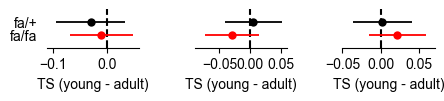

In [17]:
f, axes = plt.subplots(1, 3, figsize=(5, 0.5))
plt.subplots_adjust(wspace=0.6)

for ax, ts_, tle in zip(axes, (ts_bsl, ts_vehicle, ts_empa), ('Baseilne 1', 'Vehicle', 'Empagliflozin')):
    ax = forestplot_oz(ax, ts_);
    # ax.set_title(tle);
    ax.spines[['top', 'right', 'left']].set_visible(False)
    ax.set_xlabel('TS (young - adult)')
    
axes[0].set_xlim(-0.11,0.06)
axes[1].set_xlim(-0.09, 0.06)
axes[2].set_xlim(-0.05, 0.07)

axes[2].set_yticks([],[])
axes[1].set_yticks([],[])
# plt.tight_layout()
# f.savefig(PLOT_DIR / "ts_bp_CompareAgeForGtypsSexes.pdf", bbox_inches="tight")

## TS representing the difference between males and females

In [18]:
ts_empa, ts_vehicle, ts_bsl = (
    {
        "fa/fa":  t_groups["fa/fa:male:adult"] - t_groups["fa/fa:female:adult"],
        # "young fa/fa":   t_groups["fa/fa:male:young"] - t_groups["fa/fa:female:young"],
        "fa/+":   t_groups["fa/+:male:adult"] - t_groups["fa/+:female:adult"],
        # "young fa/+":   t_groups["fa/+:male:young"] - t_groups["fa/+:female:young"],
        # "adult": (t_groups["fa/fa:male:adult"] - t_groups["fa/+:male:adult"] + t_groups["fa/fa:female:adult"] - t_groups["fa/+:female:adult"])/2,
        # "young": (t_groups["fa/fa:male:young"] - t_groups["fa/+:male:young"] + t_groups["fa/fa:female:young"] - t_groups["fa/+:female:young"])/2,
        # "overall": (t_groups["fa/fa:young"]+t_groups["fa/fa:old"])/2 - (t_groups["fa/+:young"]+t_groups["fa/+:old"])/2,
        
    }
    for t_groups in (t_groups_empa, t_groups_vehicle, t_groups_bsl)
)

sign_probabilities_sex = pd.DataFrame({
    'empa':get_sign_probs(ts_empa),
    'empa_signif':{k:get_signif(v) for k,v in get_sign_probs(ts_empa).items()},
    'vehicle':get_sign_probs(ts_vehicle),
    'vehicle_signif':{k:get_signif(v) for k,v in get_sign_probs(ts_vehicle).items()},
    'baseline1':get_sign_probs(ts_bsl),
    'baseline1_signif':{k:get_signif(v) for k,v in get_sign_probs(ts_bsl).items()}
})

print("Empa sign probabilities:")
display(get_sign_probs(ts_empa))
print("\nVehicle sign probabilities:")
display(get_sign_probs(ts_vehicle))
print("\nBaseline 1 sign probabilities:")
display(get_sign_probs(ts_bsl))

Empa sign probabilities:


{'fa/fa': 0.00125, 'fa/+': 0.1555}


Vehicle sign probabilities:


{'fa/fa': 0.13425, 'fa/+': 0.34325}


Baseline 1 sign probabilities:


{'fa/fa': 0.5805, 'fa/+': 0.037}

[]

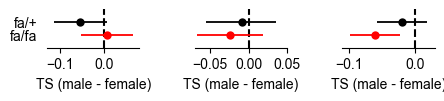

In [19]:
f, axes = plt.subplots(1, 3, figsize=(5, 0.5))
plt.subplots_adjust(wspace=0.6)

for ax, ts_, tle in zip(axes, (ts_bsl, ts_vehicle, ts_empa), ('Baseilne 1', 'Vehicle', 'Empagliflozin')):
    ax = forestplot_oz(ax, ts_);
    # ax.set_title(tle);
    ax.spines[['top', 'right', 'left']].set_visible(False)
    ax.set_xlabel('TS (male - female)')
    
axes[0].set_xlim(-0.13,0.08)
axes[1].set_xlim(-0.07, 0.05)
axes[2].set_xlim(-0.11, 0.03)

axes[2].set_yticks([],[])
axes[1].set_yticks([],[])
# f.savefig(PLOT_DIR / "ts_bp_CompareSexesForGtypAges.pdf", bbox_inches="tight")

## Show sign probabilities in tables

In [20]:
sp_all = pd.concat(objs=(sign_probabilities_change,
                sign_probabilities_gtyp,
                sign_probabilities_age, 
                sign_probabilities_sex), 
                   keys=('bp change',
                         'fa/fa - fa/+',
                         'young - adult', 
                         'male - female'), 
                   names=('contrast', 
                          'group'))
# sp_all.to_csv('../sp_tables/mean_bp.csv')
sp_all

empa empa_signif  vehicle vehicle_signif  \
contrast      group                                                        
bp change     fa/fa adult M  0.00000           *  0.91150                  
              fa/fa young M  0.00025           *  0.40625                  
              fa/+ adult M   0.73450              0.94025                  
              fa/+ young M   0.76300              0.96300                  
              fa/fa adult F  0.12575              0.99725              *   
              fa/fa young F  0.58875              0.84450                  
              fa/+ adult F   0.98025           *  0.99350              *   
              fa/+ young F   0.93675              0.97000                  
              fa/+           0.98000           *  0.99950              *   
              fa/fa          0.00025           *  0.97650              *   
fa/fa - fa/+  M adult        0.00000           *  0.41900                  
              M young        0.00325           *  0.07300                  
              F adult        0.01250           *  0.65000                  
              F young        0.15100              0.19475                  
              overall        0.00000           *  0.15800                  
young - adult fa/fa          0.88125              0.07925                  
              fa/+           0.52725              0.58625                  
male - female fa/fa          0.00125           *  0.13425                  
              fa/+           0.15550              0.34325                  

                             baseline1 baseline1_signif  
contrast      group                                      
bp change     fa/fa adult M        NaN              NaN  
              fa/fa young M        NaN              NaN  
              fa/+ adult M         NaN              NaN  
              fa/+ young M         NaN              NaN  
              fa/fa adult F        NaN              NaN  
              fa/fa young F        NaN              NaN  
              fa/+ adult F         NaN              NaN  
              fa/+ young F         NaN              NaN  
              fa/+                 NaN              NaN  
              fa/fa                NaN              NaN  
fa/fa - fa/+  M adult          0.55750                   
              M young          0.74575                   
              F adult          0.03475                   
              F young          0.18225                   
              overall          0.22800                   
young - adult fa/fa            0.35075                   
              fa/+             0.17200                   
male - female fa/fa            0.58050                   
              fa/+             0.03700